##  Install dependencies:

In [5]:
# Cell 1
!pip install transformers datasets huggingface_hub sentencepiece emoji loguru -q

print("✅ Done")

✅ Done


## Imports:

In [6]:
# Cell 2
import os
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from kaggle_secrets import UserSecretsClient
import warnings
warnings.filterwarnings('ignore')

# ── Device setup ───────────────────────────────────────────
# Why check this first? If GPU isn't enabled, training will
# take 10x longer. Always verify before starting.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device     : {device}")
print(f"GPU count  : {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"GPU name   : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device     : cuda
GPU count  : 2
GPU name   : Tesla T4
GPU memory : 15.6 GB


## Config (all hyperparams in one place):

In [7]:
# Cell 3 — Central Config
# Why centralize? Change one value, updates everywhere.
# No hunting through 10 cells to find learning rate.

CONFIG = {
    # Model
    'model_name'    : 'google/muril-base-cased',
    'num_labels'    : 2,
    'max_length'    : 128,       # 128 covers 95%+ of our texts (avg=28 words)

    # Training
    'batch_size'    : 32,        # 32 for T4, reduce to 16 if OOM
    'epochs'        : 4,         # 3-5 is sweet spot for BERT fine-tuning
    'learning_rate' : 2e-5,      # Standard for BERT (1e-5 to 5e-5)
    'warmup_ratio'  : 0.1,       # 10% of steps for warmup
    'weight_decay'  : 0.01,      # L2 regularization

    # Labels
    'label2id'      : {'NOT': 0, 'HOF': 1},
    'id2label'      : {0: 'NOT', 1: 'HOF'},

    # Paths
    'output_dir'    : '/kaggle/working/muril_model',
    'hf_repo'       : 'sourabh5500/hate-speech-muril',

    # Reproducibility
    'seed'          : 42,
}

# Set seeds everywhere for reproducibility
import random
random.seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
torch.manual_seed(CONFIG['seed'])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG['seed'])

print("✅ Config set")
for k, v in CONFIG.items():
    print(f"  {k:20s} : {v}")

✅ Config set
  model_name           : google/muril-base-cased
  num_labels           : 2
  max_length           : 128
  batch_size           : 32
  epochs               : 4
  learning_rate        : 2e-05
  warmup_ratio         : 0.1
  weight_decay         : 0.01
  label2id             : {'NOT': 0, 'HOF': 1}
  id2label             : {0: 'NOT', 1: 'HOF'}
  output_dir           : /kaggle/working/muril_model
  hf_repo              : sourabh5500/hate-speech-muril
  seed                 : 42


##  Load data:

In [8]:
# Cell 4 — Load Data
import os

# Find file paths
for dirname, _, filenames in os.walk('/kaggle/input'):
    for f in filenames:
        print(os.path.join(dirname, f))

/kaggle/input/datasets/sourabhsaxena/hatespeech01/val.csv
/kaggle/input/datasets/sourabhsaxena/hatespeech01/train.csv
/kaggle/input/datasets/sourabhsaxena/hatespeech01/test.csv


In [9]:
# Update paths based on output above
BASE = '/kaggle/input/datasets/sourabhsaxena/hatespeech01'   # ← update this

train_df = pd.read_csv(f'{BASE}/train.csv')
val_df   = pd.read_csv(f'{BASE}/val.csv')
test_df  = pd.read_csv(f'{BASE}/test.csv')

# Clean up
for df in [train_df, val_df, test_df]:
    df['text']  = df['text'].fillna('').astype(str)
    df['label'] = df['label'].astype(int)

print(f"Train : {len(train_df)} | Val : {len(val_df)} | Test : {len(test_df)}")
print(f"\nTrain label dist:\n{train_df['label'].value_counts()}")
print(f"\nVal label dist:\n{val_df['label'].value_counts()}")

Train : 20672 | Val : 2954 | Test : 5907

Train label dist:
label
0    11071
1     9601
Name: count, dtype: int64

Val label dist:
label
0    1582
1    1372
Name: count, dtype: int64


## Tokenizer:

In [10]:
# Cell 5 — Load Tokenizer
# MuRIL = Multilingual Representations for Indian Languages
# Trained on 17 Indian languages + transliterated text
# Much better than mBERT for Hinglish

print(f"Loading tokenizer: {CONFIG['model_name']}")
tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])

# Test it on a Hinglish sample
sample = "Modi ji bahut acha kaam kar rahe hain yaar"
tokens = tokenizer(sample, return_tensors='pt')
print(f"\nSample text    : {sample}")
print(f"Token IDs      : {tokens['input_ids']}")
print(f"Num tokens     : {tokens['input_ids'].shape[1]}")
print(f"Decoded tokens : {tokenizer.convert_ids_to_tokens(tokens['input_ids'][0])}")
print(f"\n✅ Tokenizer loaded — vocab size: {tokenizer.vocab_size}")

Loading tokenizer: google/muril-base-cased


config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]


Sample text    : Modi ji bahut acha kaam kar rahe hain yaar
Token IDs      : tensor([[  104,  8865,  5521,  5208, 22115,  4942,  1742,  3339,  3108, 51206,
           105]])
Num tokens     : 11
Decoded tokens : ['[CLS]', 'Modi', 'ji', 'bahut', 'acha', 'kaam', 'kar', 'rahe', 'hain', 'yaar', '[SEP]']

✅ Tokenizer loaded — vocab size: 197258


## Dataset class:

In [11]:
# Cell 6 — PyTorch Dataset
# Why custom Dataset class?
# PyTorch DataLoader needs this interface to batch data efficiently.
# It handles tokenization lazily (per sample) instead of all at once
# — saves memory on large datasets.

class HateSpeechDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts      = texts
        self.labels     = labels
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        # Required by DataLoader — tells it how many samples exist
        return len(self.texts)

    def __getitem__(self, idx):
        # Called by DataLoader for each sample
        # Tokenize here (not upfront) to save RAM
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding='max_length',    # Pad short sequences
            truncation=True,         # Truncate long sequences
            return_tensors='pt'      # Return PyTorch tensors
        )
        return {
            # squeeze() removes the batch dim added by return_tensors='pt'
            'input_ids'      : encoding['input_ids'].squeeze(),
            'attention_mask' : encoding['attention_mask'].squeeze(),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long)
        }


# Create datasets
train_dataset = HateSpeechDataset(
    train_df['text'].tolist(),
    train_df['label'].tolist(),
    tokenizer,
    CONFIG['max_length']
)
val_dataset = HateSpeechDataset(
    val_df['text'].tolist(),
    val_df['label'].tolist(),
    tokenizer,
    CONFIG['max_length']
)
test_dataset = HateSpeechDataset(
    test_df['text'].tolist(),
    test_df['label'].tolist(),
    tokenizer,
    CONFIG['max_length']
)

# Create DataLoaders
# num_workers=2: parallel data loading while GPU trains
# pin_memory=True: faster CPU→GPU transfer
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,           # Shuffle train data every epoch
    num_workers=2,
    pin_memory=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'] * 2,   # 2x batch for eval (no gradients)
    shuffle=False,
    num_workers=2,
    pin_memory=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'] * 2,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

# Verify one batch
batch = next(iter(train_loader))
print(f"\nSample batch:")
print(f"  input_ids shape      : {batch['input_ids'].shape}")
print(f"  attention_mask shape : {batch['attention_mask'].shape}")
print(f"  labels shape         : {batch['label'].shape}")

Train batches : 646
Val batches   : 47
Test batches  : 93

Sample batch:
  input_ids shape      : torch.Size([32, 128])
  attention_mask shape : torch.Size([32, 128])
  labels shape         : torch.Size([32])


## Load model:

In [12]:
# Cell 7 — Load MuRIL Model
# AutoModelForSequenceClassification adds a classification head
# on top of MuRIL's [CLS] token output.
# Architecture: MuRIL → [CLS] embedding → Dropout → Linear(768, 2)

print(f"Loading model: {CONFIG['model_name']}")
model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG['model_name'],
    num_labels=CONFIG['num_labels'],
    id2label=CONFIG['id2label'],
    label2id=CONFIG['label2id'],
)
model = model.to(device)

# Count parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal params     : {total_params:,}")
print(f"Trainable params : {trainable_params:,}")
print(f"Model size       : ~{total_params * 4 / 1e6:.0f} MB")
print(f"\n✅ Model loaded on {device}")

Loading model: google/muril-base-cased


pytorch_model.bin:   0%|          | 0.00/953M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/953M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google/muril-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expe


Total params     : 237,557,762
Trainable params : 237,557,762
Model size       : ~950 MB

✅ Model loaded on cuda


## Optimizer + Scheduler:

In [13]:
# Cell 8 — Optimizer & Scheduler

# Why AdamW over Adam?
# AdamW fixes weight decay implementation in Adam.
# Standard choice for transformer fine-tuning.

# Why different LR for different layers?
# Lower layers (embeddings) already know language — fine-tune gently
# Upper layers (task-specific) need more aggressive updates
# This is called "discriminative learning rates" — advanced technique

no_decay = ['bias', 'LayerNorm.weight']  # These params don't need weight decay

optimizer_grouped_params = [
    {
        # All params EXCEPT bias and LayerNorm — apply weight decay
        'params': [p for n, p in model.named_parameters()
                   if not any(nd in n for nd in no_decay)],
        'weight_decay': CONFIG['weight_decay'],
    },
    {
        # bias and LayerNorm params — NO weight decay
        'params': [p for n, p in model.named_parameters()
                   if any(nd in n for nd in no_decay)],
        'weight_decay': 0.0,
    }
]

optimizer = AdamW(optimizer_grouped_params, lr=CONFIG['learning_rate'])

# Linear warmup then decay scheduler
# Why warmup? Large LR at start can destroy pretrained weights.
# We start small, ramp up, then decay.
total_steps  = len(train_loader) * CONFIG['epochs']
warmup_steps = int(total_steps * CONFIG['warmup_ratio'])

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"Total training steps : {total_steps}")
print(f"Warmup steps         : {warmup_steps}")
print(f"Optimizer            : AdamW (lr={CONFIG['learning_rate']})")
print(f"Scheduler            : Linear warmup + decay")

Total training steps : 2584
Warmup steps         : 258
Optimizer            : AdamW (lr=2e-05)
Scheduler            : Linear warmup + decay


## Training functions:

In [14]:
# Cell 9 — Train & Eval Functions

def train_epoch(model, loader, optimizer, scheduler, device):
    """One full pass through training data."""
    model.train()   # Enable dropout, batch norm in train mode
    total_loss, all_preds, all_labels = 0, [], []

    for batch_idx, batch in enumerate(loader):
        # Move batch to GPU
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        # Forward pass
        optimizer.zero_grad()   # Clear gradients from previous step
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels       # When labels passed, model computes loss internally
        )

        loss = outputs.loss
        logits = outputs.logits

        # Backward pass
        loss.backward()         # Compute gradients

        # Gradient clipping — prevents exploding gradients
        # Standard practice for transformer fine-tuning
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()        # Update weights
        scheduler.step()        # Update learning rate

        # Collect predictions
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        total_loss += loss.item()

        # Progress update every 100 batches
        if (batch_idx + 1) % 100 == 0:
            print(f"  Batch {batch_idx+1}/{len(loader)} | Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(loader)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, macro_f1


def evaluate(model, loader, device):
    """Evaluate on val or test set."""
    model.eval()    # Disable dropout — deterministic predictions
    total_loss, all_preds, all_labels = 0, [], []

    with torch.no_grad():   # No gradient computation needed for eval
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss   = outputs.loss
            logits = outputs.logits

            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
            total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, macro_f1, all_preds, all_labels


print("✅ Training functions defined")

✅ Training functions defined


##  Training loop:

In [15]:
# Cell 10 — Main Training Loop

import os
os.makedirs(CONFIG['output_dir'], exist_ok=True)

print("="*60)
print("STARTING MURIL FINE-TUNING")
print("="*60)
print(f"Model    : {CONFIG['model_name']}")
print(f"Epochs   : {CONFIG['epochs']}")
print(f"Batch    : {CONFIG['batch_size']}")
print(f"LR       : {CONFIG['learning_rate']}")
print(f"Device   : {device}")
print("="*60)

best_val_f1  = 0.0
best_epoch   = 0
history      = []

for epoch in range(1, CONFIG['epochs'] + 1):
    print(f"\n── Epoch {epoch}/{CONFIG['epochs']} ──────────────────────────")

    # Train
    train_loss, train_f1 = train_epoch(
        model, train_loader, optimizer, scheduler, device
    )

    # Validate
    val_loss, val_f1, val_preds, val_labels = evaluate(
        model, val_loader, device
    )

    # Log
    history.append({
        'epoch'      : epoch,
        'train_loss' : train_loss,
        'train_f1'   : train_f1,
        'val_loss'   : val_loss,
        'val_f1'     : val_f1,
    })

    print(f"\n  Train Loss : {train_loss:.4f} | Train Macro-F1 : {train_f1:.4f}")
    print(f"  Val Loss   : {val_loss:.4f} | Val Macro-F1   : {val_f1:.4f}")

    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch  = epoch
        model.save_pretrained(CONFIG['output_dir'])
        tokenizer.save_pretrained(CONFIG['output_dir'])
        print(f"  ✅ New best model saved! (Val F1: {val_f1:.4f})")
    else:
        print(f"  ⏭ No improvement (best: {best_val_f1:.4f} @ epoch {best_epoch})")

print("\n" + "="*60)
print(f"TRAINING COMPLETE")
print(f"Best Val Macro-F1 : {best_val_f1:.4f} (Epoch {best_epoch})")
print("="*60)

STARTING MURIL FINE-TUNING
Model    : google/muril-base-cased
Epochs   : 4
Batch    : 32
LR       : 2e-05
Device   : cuda

── Epoch 1/4 ──────────────────────────
  Batch 100/646 | Loss: 0.6909
  Batch 200/646 | Loss: 0.6708
  Batch 300/646 | Loss: 0.6762
  Batch 400/646 | Loss: 0.5944
  Batch 500/646 | Loss: 0.6004
  Batch 600/646 | Loss: 0.6045

  Train Loss : 0.6356 | Train Macro-F1 : 0.6269
  Val Loss   : 0.5718 | Val Macro-F1   : 0.7095


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ New best model saved! (Val F1: 0.7095)

── Epoch 2/4 ──────────────────────────
The OrderedVocab you are attempting to save contains holes for indices [202, 437, 1046, 1057, 1118, 1135, 1150, 1162, 1318, 1445, 1473, 1610, 1626, 1775, 3517, 3643, 4513, 5830, 7834, 12787, 13244, 19712, 25184, 27726, 28024, 31739, 65274], your vocabulary could be corrupted!
  Batch 100/646 | Loss: 0.5607
  Batch 200/646 | Loss: 0.4953
  Batch 300/646 | Loss: 0.5336
  Batch 400/646 | Loss: 0.4188
  Batch 500/646 | Loss: 0.4356
  Batch 600/646 | Loss: 0.4300

  Train Loss : 0.5232 | Train Macro-F1 : 0.7387
  Val Loss   : 0.5178 | Val Macro-F1   : 0.7293


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ New best model saved! (Val F1: 0.7293)

── Epoch 3/4 ──────────────────────────
The OrderedVocab you are attempting to save contains holes for indices [202, 437, 1046, 1057, 1118, 1135, 1150, 1162, 1318, 1445, 1473, 1610, 1626, 1775, 3517, 3643, 4513, 5830, 7834, 12787, 13244, 19712, 25184, 27726, 28024, 31739, 65274], your vocabulary could be corrupted!
  Batch 100/646 | Loss: 0.5551
  Batch 200/646 | Loss: 0.5908
  Batch 300/646 | Loss: 0.4295
  Batch 400/646 | Loss: 0.3282
  Batch 500/646 | Loss: 0.4287
  Batch 600/646 | Loss: 0.5111

  Train Loss : 0.4444 | Train Macro-F1 : 0.7869
  Val Loss   : 0.5141 | Val Macro-F1   : 0.7324


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

The OrderedVocab you are attempting to save contains holes for indices [202, 437, 1046, 1057, 1118, 1135, 1150, 1162, 1318, 1445, 1473, 1610, 1626, 1775, 3517, 3643, 4513, 5830, 7834, 12787, 13244, 19712, 25184, 27726, 28024, 31739, 65274], your vocabulary could be corrupted!
  ✅ New best model saved! (Val F1: 0.7324)

── Epoch 4/4 ──────────────────────────
  Batch 100/646 | Loss: 0.3119
  Batch 200/646 | Loss: 0.4577
  Batch 300/646 | Loss: 0.2972
  Batch 400/646 | Loss: 0.3702
  Batch 500/646 | Loss: 0.2528
  Batch 600/646 | Loss: 0.4375

  Train Loss : 0.3876 | Train Macro-F1 : 0.8196
  Val Loss   : 0.5410 | Val Macro-F1   : 0.7290
  ⏭ No improvement (best: 0.7324 @ epoch 3)

TRAINING COMPLETE
Best Val Macro-F1 : 0.7324 (Epoch 3)


## Plot training history:

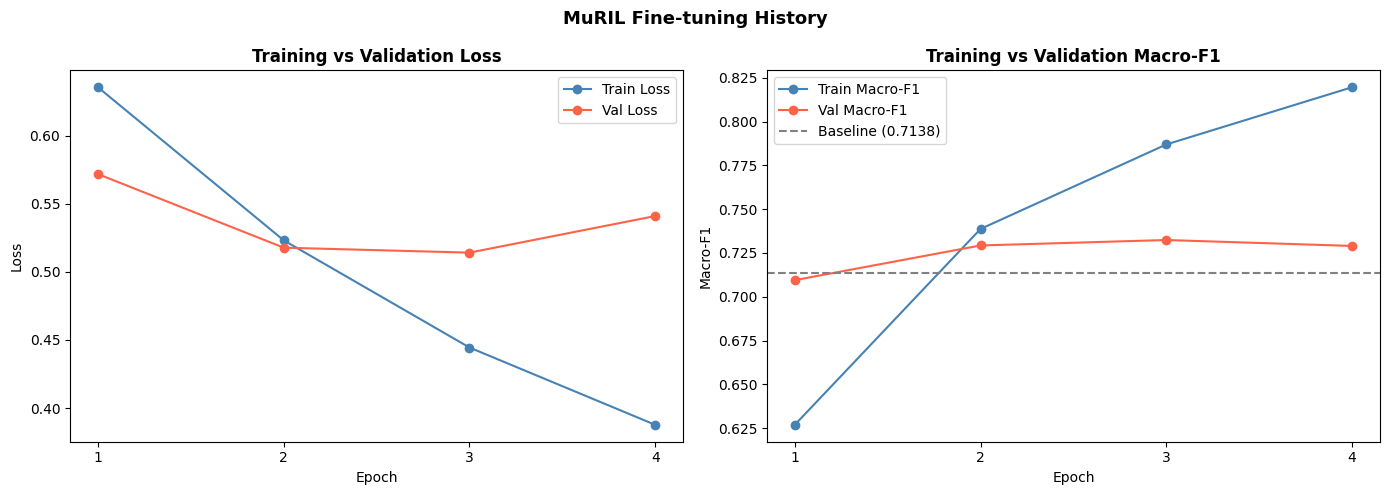

 epoch  train_loss  train_f1  val_loss   val_f1
     1    0.635631  0.626871  0.571823 0.709476
     2    0.523185  0.738693  0.517775 0.729265
     3    0.444432  0.786933  0.514126 0.732374
     4    0.387642  0.819596  0.541009 0.728992


In [16]:
# Cell 11 — Training Curves
import matplotlib.pyplot as plt

history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history_df['epoch'], history_df['train_loss'],
             'o-', label='Train Loss', color='steelblue')
axes[0].plot(history_df['epoch'], history_df['val_loss'],
             'o-', label='Val Loss', color='tomato')
axes[0].set_title('Training vs Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].set_xticks(history_df['epoch'])

# F1
axes[1].plot(history_df['epoch'], history_df['train_f1'],
             'o-', label='Train Macro-F1', color='steelblue')
axes[1].plot(history_df['epoch'], history_df['val_f1'],
             'o-', label='Val Macro-F1', color='tomato')
axes[1].axhline(y=0.7138, color='gray', linestyle='--',
                label='Baseline (0.7138)')
axes[1].set_title('Training vs Validation Macro-F1', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Macro-F1')
axes[1].legend()
axes[1].set_xticks(history_df['epoch'])

plt.suptitle('MuRIL Fine-tuning History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(history_df.to_string(index=False))

## Final test evaluation:

In [17]:
# Cell 12 — Test Set Evaluation (load best saved model)
from transformers import AutoModelForSequenceClassification, AutoTokenizer

print("Loading best saved model...")
best_model = AutoModelForSequenceClassification.from_pretrained(CONFIG['output_dir'])
best_model = best_model.to(device)

test_loss, test_f1, test_preds, test_labels = evaluate(
    best_model, test_loader, device
)

print("\n" + "="*60)
print("FINAL TEST SET EVALUATION — MuRIL")
print("="*60)
print(classification_report(
    test_labels, test_preds,
    target_names=['NOT (0)', 'HOF (1)'],
    digits=4
))
print(f"Test Macro-F1  : {test_f1:.4f}  ← PRIMARY METRIC")
print(f"\nBaseline F1    : 0.7138")
print(f"Improvement    : +{(test_f1 - 0.7138):.4f} ({((test_f1-0.7138)/0.7138*100):.1f}% relative gain)")

Loading best saved model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


FINAL TEST SET EVALUATION — MuRIL
              precision    recall  f1-score   support

     NOT (0)     0.7351    0.8015    0.7669      3164
     HOF (1)     0.7444    0.6668    0.7035      2743

    accuracy                         0.7390      5907
   macro avg     0.7397    0.7342    0.7352      5907
weighted avg     0.7394    0.7390    0.7374      5907

Test Macro-F1  : 0.7352  ← PRIMARY METRIC

Baseline F1    : 0.7138
Improvement    : +0.0214 (3.0% relative gain)


## Push to HuggingFace:

In [18]:
# Cell 13 — Push to HuggingFace Hub

from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

# Get token from Kaggle secrets
hf_token = UserSecretsClient().get_secret("HF_TOKEN")
login(token=hf_token)

print(f"Pushing to HuggingFace: {CONFIG['hf_repo']}")

# Push model + tokenizer
best_model.push_to_hub(CONFIG['hf_repo'])
tokenizer.push_to_hub(CONFIG['hf_repo'])

print(f"\n✅ Model pushed!")
print(f"🔗 https://huggingface.co/{CONFIG['hf_repo']}")

Pushing to HuggingFace: sourabh5500/hate-speech-muril


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

The OrderedVocab you are attempting to save contains holes for indices [202, 437, 1046, 1057, 1118, 1135, 1150, 1162, 1318, 1445, 1473, 1610, 1626, 1775, 3517, 3643, 4513, 5830, 7834, 12787, 13244, 19712, 25184, 27726, 28024, 31739, 65274], your vocabulary could be corrupted!

✅ Model pushed!
🔗 https://huggingface.co/sourabh5500/hate-speech-muril


## Save all results:

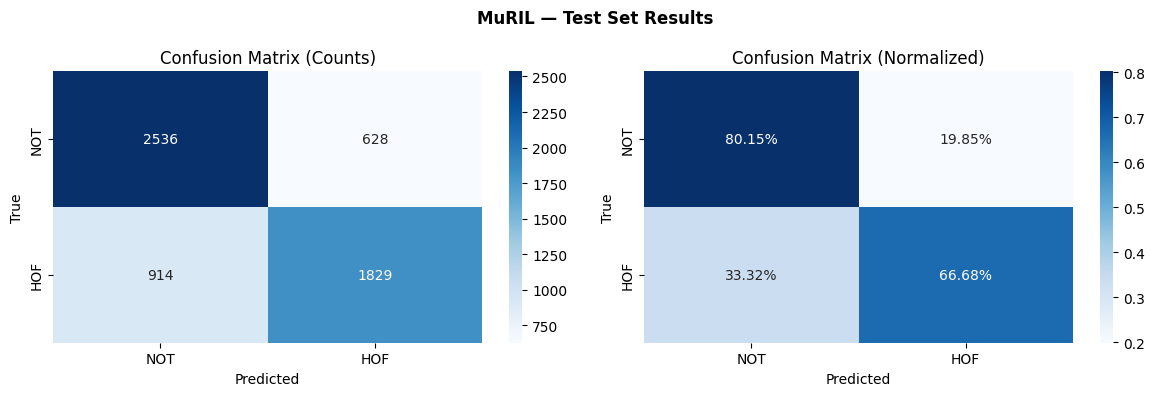


📊 FINAL SUMMARY
Baseline Macro-F1 : 0.7138
MuRIL Macro-F1    : 0.7352
Improvement       : +0.0214
HF Model          : sourabh5500/hate-speech-muril

✅ All results saved!


In [19]:
# Cell 14 — Save Results

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NOT','HOF'],
            yticklabels=['NOT','HOF'], ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['NOT','HOF'],
            yticklabels=['NOT','HOF'], ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)')
axes[1].set_ylabel('True')
axes[1].set_xlabel('Predicted')

plt.suptitle('MuRIL — Test Set Results', fontweight='bold')
plt.tight_layout()
plt.savefig('muril_confusion_matrix.png', dpi=150)
plt.show()

# Save results CSV
results = pd.DataFrame([{
    'model'     : 'MuRIL-base-cased',
    'macro_f1'  : test_f1,
    'baseline'  : 0.7138,
    'gain'      : test_f1 - 0.7138,
    'epochs'    : CONFIG['epochs'],
    'batch_size': CONFIG['batch_size'],
    'lr'        : CONFIG['learning_rate'],
    'max_length': CONFIG['max_length'],
    'hf_repo'   : CONFIG['hf_repo'],
}])
results.to_csv('/kaggle/working/muril_results.csv', index=False)

print("\n📊 FINAL SUMMARY")
print("="*50)
print(f"Baseline Macro-F1 : 0.7138")
print(f"MuRIL Macro-F1    : {test_f1:.4f}")
print(f"Improvement       : +{test_f1-0.7138:.4f}")
print(f"HF Model          : {CONFIG['hf_repo']}")
print("="*50)
print("\n✅ All results saved!")